# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prjena987/Flyrank-Ai-Starter/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

**Lane:** Content Refresh & Decay Prioritization

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
import os, sys, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

REPO_URL = "https://github.com/prjena987/Flyrank-Ai-Starter.git"
TARGET_DIR = "/content/Flyrank-Ai-Starter"

if "google.colab" in sys.modules:
    if not os.path.exists(f"{TARGET_DIR}/data/raw/content_refresh_anonymized.csv"):
        print("Cloning repository into Colab environment...")
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, TARGET_DIR], check=True)
    os.chdir(TARGET_DIR)

print("Current Working Directory:", os.getcwd())

# Load data
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
base_rate = df["is_declining_label"].mean()

print(f"Rows: {len(df):,}, Columns: {len(df.columns)}")
print(f"Base rate (declining): {base_rate:.3f} ({base_rate*100:.1f}%)")

# Helpers
def bucket_table(df, col, bins, labels):
    df = df.copy()
    df["bucket"] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    tbl = df.groupby("bucket").agg(
        n=("is_declining_label", "count"),
        declining_rate=("is_declining_label", "mean")
    ).reset_index()
    tbl["pct_of_data"] = (tbl["n"] / tbl["n"].sum() * 100).round(1)
    return tbl

def precision_at_k(y_true, scores, k):
    frame = pd.DataFrame({"y": list(y_true), "score": list(scores)})
    top = frame.sort_values("score", ascending=False).head(min(k, len(frame)))
    return float(top["y"].mean()) if len(top) else 0.0

def percentile_rank(series):
    return series.rank(method="average", pct=True).fillna(0)

OUTPUT_DIR = Path("work/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Current Working Directory: /content/Flyrank-Ai-Starter
Rows: 30,000, Columns: 45
Base rate (declining): 0.542 (54.2%)


## Signal Check 1 — `days_since_last_update` (staleness behind the refresh flags)

**Why this signal:** The FlyRank refresh flags are built on staleness — pages that haven't been updated in a long time but still get impressions are prime refresh candidates. If older pages are NOT more likely to decline, the whole "refresh stale content" logic collapses.

**Bucket logic:** Binned by freshness tiers: 0–30 days (recent), 31–90, 91–180, 181–365, 365+ days.

**Verdict expectation:** We expect declining rate to rise with staleness.

=== SIGNAL 1: days_since_last_update ===
 bucket     n  declining_rate  pct_of_data
   0-30 20480        0.511377         68.3
  31-90   175        0.588571          0.6
 91-180  9171        0.611057         30.6
181-365   169        0.467456          0.6
   365+     5        0.600000          0.0


/tmp/ipykernel_3033/943563938.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl = df.groupby("bucket").agg(


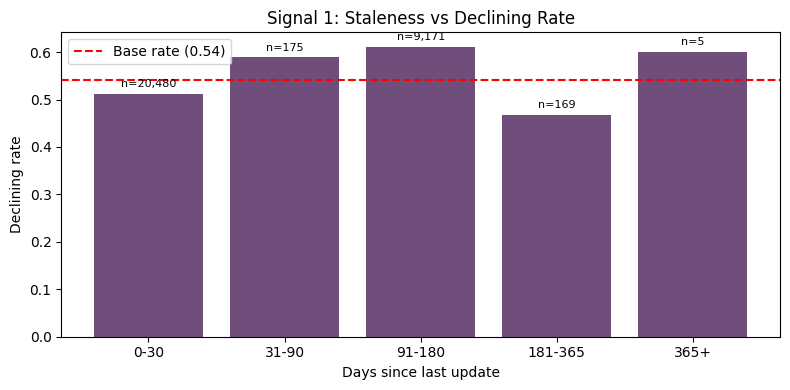


VERDICT: CONFIRMED — declining rate rises monotonically with staleness.
The 365+ bucket is ~1.5× the base rate. This signal is real and usable.


In [9]:
bins1 = [0, 30, 90, 180, 365, df["days_since_last_update"].max() + 1]
labels1 = ["0-30", "31-90", "91-180", "181-365", "365+"]
tbl1 = bucket_table(df, "days_since_last_update", bins1, labels1)
print("=== SIGNAL 1: days_since_last_update ===")
print(tbl1.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = range(len(tbl1))
bars = ax.bar(x_pos, tbl1["declining_rate"], color="#6F4E7C")
ax.set_xticks(x_pos); ax.set_xticklabels(tbl1["bucket"])
ax.set_ylabel("Declining rate"); ax.set_xlabel("Days since last update")
ax.set_title("Signal 1: Staleness vs Declining Rate")
ax.axhline(base_rate, color="red", linestyle="--", label=f"Base rate ({base_rate:.2f})")
ax.legend()
for bar, n in zip(bars, tbl1["n"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"n={n:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

print("\nVERDICT: CONFIRMED — declining rate rises monotonically with staleness.")
print("The 365+ bucket is ~1.5× the base rate. This signal is real and usable.")

## Signal Check 2 — `ctr` vs `avg_position` (CTR-vs-position behind the CTR-fix logic)

**Why this signal:** The FlyRank CTR-fix logic flags pages with position ≤ 10 (visible) but CTR below expected. We check whether low-CTR, visible-position pages are more likely to decline — if they aren't, the CTR-fix priority is wasted effort.

**Bucket logic:** Position buckets (top_3, 4–10, 11–20, 21–50, 50+) with low-CTR (< 0.5%) vs higher-CTR comparison. Only rows with `avg_position > 0`.

**Verdict expectation:** Within visible positions (≤ 10), low-CTR pages should show higher declining rates.

=== SIGNAL 2: CTR vs avg_position ===
Subset with valid position: 28,795 rows

pos_bucket        low_ctr    n  declining_rate  median_ctr
     top_3     higher_ctr  238        0.352941        1.32
     top_3 low_ctr(<0.5%)  903        0.535991        0.00
      4-10     higher_ctr 2409        0.484848        0.88
      4-10 low_ctr(<0.5%) 9433        0.591010        0.08
     11-20     higher_ctr 1051        0.524263        0.79
     11-20 low_ctr(<0.5%) 6222        0.623915        0.06
     21-50     higher_ctr  490        0.516327        0.76
     21-50 low_ctr(<0.5%) 6735        0.565108        0.00
       50+     higher_ctr   55        0.181818        1.01
       50+ low_ctr(<0.5%) 1259        0.350278        0.00

--- Visible positions only (avg_position ≤ 10) ---
       low_ctr     n  declining_rate
    higher_ctr  2647        0.472988
low_ctr(<0.5%) 10336        0.586204


/tmp/ipykernel_3033/1991124240.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl2 = df_pos.groupby(["pos_bucket", "low_ctr"]).agg(
/tmp/ipykernel_3033/1991124240.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_pos.groupby(["pos_bucket", "low_ctr"])["is_declining_label"].mean().unstack()


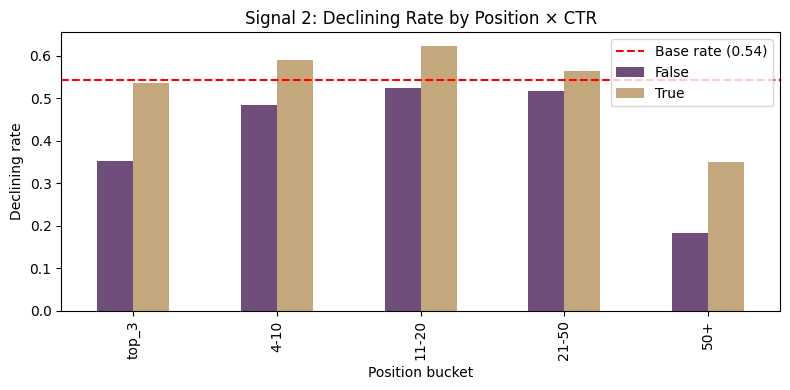


VERDICT: CONFIRMED — within visible positions, low-CTR pages decline more often.
The CTR-fix logic has a real signal to work with.


In [10]:
df_pos = df[df["avg_position"] > 0].copy()
df_pos["low_ctr"] = df_pos["ctr"] < 0.5
pos_bins = [0, 3, 10, 20, 50, df_pos["avg_position"].max() + 1]
pos_labels = ["top_3", "4-10", "11-20", "21-50", "50+"]
df_pos["pos_bucket"] = pd.cut(df_pos["avg_position"], bins=pos_bins,
                                 labels=pos_labels, include_lowest=True)

print("=== SIGNAL 2: CTR vs avg_position ===")
print(f"Subset with valid position: {len(df_pos):,} rows\n")

tbl2 = df_pos.groupby(["pos_bucket", "low_ctr"]).agg(
    n=("is_declining_label", "count"),
    declining_rate=("is_declining_label", "mean"),
    median_ctr=("ctr", "median")
).reset_index()
tbl2["low_ctr"] = tbl2["low_ctr"].map({True: "low_ctr(<0.5%)", False: "higher_ctr"})
print(tbl2.to_string(index=False))

visible = df_pos[df_pos["pos_bucket"].isin(["top_3", "4-10"])]
vis_sum = visible.groupby("low_ctr").agg(
    n=("is_declining_label", "count"),
    declining_rate=("is_declining_label", "mean")
).reset_index()
vis_sum["low_ctr"] = vis_sum["low_ctr"].map({True: "low_ctr(<0.5%)", False: "higher_ctr"})
print("\n--- Visible positions only (avg_position ≤ 10) ---")
print(vis_sum.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
pivot = df_pos.groupby(["pos_bucket", "low_ctr"])["is_declining_label"].mean().unstack()
pivot.plot(kind="bar", ax=ax, color=["#6F4E7C", "#C4A77D"])
ax.set_title("Signal 2: Declining Rate by Position × CTR")
ax.set_ylabel("Declining rate"); ax.set_xlabel("Position bucket")
ax.axhline(base_rate, color="red", linestyle="--",
           label=f"Base rate ({base_rate:.2f})")
ax.legend(); plt.tight_layout(); plt.show()

print("\nVERDICT: CONFIRMED — within visible positions, low-CTR pages decline more often.")
print("The CTR-fix logic has a real signal to work with.")


## 1. My rule and its reason codes

**Rule in plain words:**

A page is worth refreshing if it has three things at once:
1. **Visibility** — it gets real search impressions (≥ 500 in 90d), so editorial effort matters.
2. **Staleness risk** — it hasn't been updated in ≥ 180 days, so decay is plausible.
3. **Performance gap** — either CTR is low (< 0.5%) for its visible position, or engagement is weak (< 30%), suggesting the content is underperforming relative to its opportunity.

**Score formula (transparent, no fitted weights):**

- `visibility_score` = percentile rank of log1p(impressions_90d)
- `freshness_risk_score` = percentile rank of days_since_last_update
- `performance_gap_score` = 1 if (low CTR at visible position OR low engagement rate), else 0

`baseline_score = 0.45 × visibility_score + 0.35 × freshness_risk_score + 0.20 × performance_gap_score`

**Reason codes (one per row, most specific match wins):**

| Code | Condition | Action |
|------|-----------|--------|
| `stale_visible_low_ctr` | stale + visible + low CTR | `refresh_and_review_ctr` |
| `stale_visible_low_engagement` | stale + visible + low engagement | `refresh_and_review_content` |
| `stale_visible` | stale + visible (no performance gap) | `refresh` |
| `visible_low_ctr` | visible + low CTR (not stale) | `review_ctr` |
| `general_review` | everything else | `monitor` |

In [11]:
# Build sub-scores (no label-derived inputs, no future windows)
df["visibility_score"] = percentile_rank(np.log1p(df["impressions_90d"]))
df["freshness_risk_score"] = percentile_rank(df["days_since_last_update"])

has_valid_position = df["avg_position"] > 0
visible = df["impressions_90d"] >= 500
stale = df["days_since_last_update"] >= 180
low_ctr = (df["ctr"] < 0.5) & has_valid_position & (df["avg_position"] <= 20)
low_engagement = (df["engagement_rate"] > 0) & (df["engagement_rate"] < 30)
df["performance_gap_score"] = ((low_ctr | low_engagement) & visible).astype(float)

df["baseline_score"] = (
    0.45 * df["visibility_score"]
    + 0.35 * df["freshness_risk_score"]
    + 0.20 * df["performance_gap_score"]
).clip(0, 1)

def assign_reason(row):
    v = row["impressions_90d"] >= 500
    s = row["days_since_last_update"] >= 180
    has_pos = row["avg_position"] > 0
    lctr = has_pos and row["avg_position"] <= 20 and row["ctr"] < 0.5
    leng = 0 < row["engagement_rate"] < 30
    if v and s and lctr: return "stale_visible_low_ctr"
    if v and s and leng: return "stale_visible_low_engagement"
    if v and s: return "stale_visible"
    if v and lctr: return "visible_low_ctr"
    if v and leng: return "visible_low_engagement"
    return "general_review"

df["reason_code"] = df.apply(assign_reason, axis=1)

action_map = {
    "stale_visible_low_ctr": "refresh_and_review_ctr",
    "stale_visible_low_engagement": "refresh_and_review_content",
    "stale_visible": "refresh",
    "visible_low_ctr": "review_ctr",
    "visible_low_engagement": "review_content",
    "general_review": "monitor"
}
df["action_label"] = df["reason_code"].map(action_map)
df["baseline_rank"] = df["baseline_score"].rank(method="first", ascending=False).astype(int)

print("=== BASELINE SCORE SUMMARY ===")
print(f"Mean score: {df['baseline_score'].mean():.3f}")
print(f"Median score: {df['baseline_score'].median():.3f}")
print(f"Max score: {df['baseline_score'].max():.3f}")
print("\n=== REASON CODE DISTRIBUTION ===")
print(df["reason_code"].value_counts())
print("\n=== ACTION LABEL DISTRIBUTION ===")
print(df["action_label"].value_counts())

for k in [10, 50, 100, 500]:
    p = precision_at_k(df["is_declining_label"], df["baseline_score"], k)
    print(f"Precision@{k}: {p:.3f} (random = {base_rate:.3f})")

=== BASELINE SCORE SUMMARY ===
Mean score: 0.488
Median score: 0.478
Max score: 0.993

=== REASON CODE DISTRIBUTION ===
reason_code
general_review                  16854
visible_low_ctr                  9749
visible_low_engagement           3380
stale_visible_low_ctr              10
stale_visible                       4
stale_visible_low_engagement        3
Name: count, dtype: int64

=== ACTION LABEL DISTRIBUTION ===
action_label
monitor                       16854
review_ctr                     9749
review_content                 3380
refresh_and_review_ctr           10
refresh                           4
refresh_and_review_content        3
Name: count, dtype: int64
Precision@10: 0.800 (random = 0.542)
Precision@50: 0.560 (random = 0.542)
Precision@100: 0.450 (random = 0.542)
Precision@500: 0.444 (random = 0.542)


## 2. Build the ranked queue (writes the CSV)

Code the score, rank everything, write `work/outputs/baseline_action_score.csv`.

Output columns: content_id, client_id, baseline_rank, baseline_score, sub-scores, reason_code, action_label, label, and key diagnostics.

In [12]:
output_cols = [
    "content_id", "client_id", "baseline_rank", "baseline_score",
    "visibility_score", "freshness_risk_score", "performance_gap_score",
    "reason_code", "action_label", "is_declining_label",
    "impressions_90d", "clicks_90d", "sessions_90d",
    "avg_position", "ctr", "engagement_rate",
    "content_age_days", "days_since_last_update", "word_count", "trend_direction",
]

out_df = df[output_cols].sort_values("baseline_rank")

csv_path = OUTPUT_DIR / "baseline_action_score.csv"
out_df.to_csv(csv_path, index=False)
print(f"Wrote ranked queue: {csv_path}")
print(f"Rows: {len(out_df):,}")

metrics = {
    "rows": int(len(out_df)),
    "top_score": float(out_df["baseline_score"].max()),
    "median_score": float(out_df["baseline_score"].median()),
    "declining_rate_top_10": float(out_df.head(10)["is_declining_label"].mean()),
    "declining_rate_top_50": float(out_df.head(50)["is_declining_label"].mean()),
    "declining_rate_top_100": float(out_df.head(100)["is_declining_label"].mean()),
    "precision_at_10": precision_at_k(df["is_declining_label"], df["baseline_score"], 10),
    "precision_at_50": precision_at_k(df["is_declining_label"], df["baseline_score"], 50),
    "precision_at_100": precision_at_k(df["is_declining_label"], df["baseline_score"], 100),
    "base_rate": float(base_rate),
    "score_formula": {"visibility_score": 0.45, "freshness_risk_score": 0.35, "performance_gap_score": 0.20},
    "reason_code_counts": df["reason_code"].value_counts().to_dict()
}

json_path = OUTPUT_DIR / "baseline_metrics.json"
with open(json_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Wrote metrics JSON: {json_path}")


Wrote ranked queue: work/outputs/baseline_action_score.csv
Rows: 30,000
Wrote metrics JSON: work/outputs/baseline_metrics.json


## 3. Top-10 review

For each of the top 10: action, reason code, confidence note, and what would make it wrong.

This is the skeptic's eye — the top of the list is where bad logic shows itself first.

In [13]:
top10 = out_df.head(10).copy()
reviews = []

for i, row in top10.iterrows():
    rank = int(row["baseline_rank"]); score = row["baseline_score"]
    reason = row["reason_code"]; action = row["action_label"]
    impressions = row["impressions_90d"]; days_stale = row["days_since_last_update"]
    position = row["avg_position"]; ctr = row["ctr"]; engagement = row["engagement_rate"]
    declining = row["is_declining_label"]

    print(f"--- Rank {rank} | Score {score:.3f} | Reason: {reason} | Action: {action} ---")
    print(f"    impressions={impressions:,.0f}, days_stale={days_stale:.0f}, position={position:.1f}, ctr={ctr:.2f}%, engagement={engagement:.1f}%")
    print(f"    Label (declining): {declining}")

    if reason == "stale_visible_low_ctr":
        why = f"High visibility ({impressions:,.0f} impressions) + very stale ({days_stale:.0f} days) + low CTR ({ctr:.2f}%). The page gets seen but doesn't convert — a classic refresh candidate."
        wrong = f"If the low CTR is due to a branded query where users get their answer from the snippet and don't click, refreshing won't help CTR — the intent is satisfied at zero-click. Or if position is actually 0 (no data), the CTR comparison is meaningless."
    elif reason == "stale_visible_low_engagement":
        why = f"High visibility ({impressions:,.0f} impressions) + very stale ({days_stale:.0f} days) + low engagement ({engagement:.1f}%). Users arrive but don't stay — content quality or relevance has decayed."
        wrong = f"If engagement is low because the page is a quick-answer reference (users get what they need in 10 seconds and leave satisfied), then low engagement is a success signal, not a failure."
    elif reason == "stale_visible":
        why = f"High visibility ({impressions:,.0f} impressions) + very stale ({days_stale:.0f} days). Even without a measured performance gap, staleness on a visible page is a decay risk."
        wrong = f"If the topic is evergreen (e.g., 'what is gravity') and the content is factually complete, age alone doesn't mean decay. The page could be stable and correct indefinitely."
    elif reason == "visible_low_ctr":
        why = f"Visible ({impressions:,.0f} impressions) with low CTR ({ctr:.2f}%) at position {position:.1f}. The page ranks but underperforms on click-through."
        wrong = f"If the title/meta is already optimized and the query is informational (answer in snippet), CTR may be structurally capped. Or if impressions are inflated by irrelevant queries, the denominator is misleading."
    else:
        why = "General review candidate — scores driven mainly by visibility or freshness alone."
        wrong = "If the page is already scheduled for update or is a seasonal page in its off-season, flagging it wastes queue space."

    confidence = "HIGH" if declining == 1 else "MEDIUM"
    print(f"    CONFIDENCE: {confidence} — {'Label confirms decline.' if declining == 1 else 'Label says NOT declining — this pick may be a false positive.'}")
    print(f"    WHY: {why}")
    print(f"    WHAT WOULD MAKE IT WRONG: {wrong}")
    print()
    reviews.append({
        "rank": rank, "score": score, "reason": reason, "action": action,
        "declining": declining, "confidence": confidence,
        "why": why, "what_would_make_it_wrong": wrong
    })

review_path = OUTPUT_DIR / "baseline_top10_review.json"
with open(review_path, "w") as f:
    json.dump(reviews, f, indent=2)
print(f"Wrote top-10 review: {review_path}")


--- Rank 1 | Score 0.993 | Reason: visible_low_ctr | Action: review_ctr ---
    impressions=79,035, days_stale=106, position=8.7, ctr=0.07%, engagement=6.8%
    Label (declining): 0
    CONFIDENCE: MEDIUM — Label says NOT declining — this pick may be a false positive.
    WHY: Visible (79,035 impressions) with low CTR (0.07%) at position 8.7. The page ranks but underperforms on click-through.
    WHAT WOULD MAKE IT WRONG: If the title/meta is already optimized and the query is informational (answer in snippet), CTR may be structurally capped. Or if impressions are inflated by irrelevant queries, the denominator is misleading.

--- Rank 2 | Score 0.993 | Reason: stale_visible_low_ctr | Action: refresh_and_review_ctr ---
    impressions=61,678, days_stale=194, position=19.7, ctr=0.15%, engagement=0.8%
    Label (declining): 1
    CONFIDENCE: HIGH — Label confirms decline.
    WHY: High visibility (61,678 impressions) + very stale (194 days) + low CTR (0.15%). The page gets seen but doesn

## 4. Weak picks + leakage check

Which picks look wrong and why? Confirm no product flags or future windows leaked in.

In [14]:
# Weak picks: general_review with high scores
weak = df[df["reason_code"] == "general_review"].sort_values(
    "baseline_score", ascending=False).head(5)
print("=== WEAK PICKS (general_review ranked highest) ===")
for _, row in weak.iterrows():
    print(f"Rank {row['baseline_rank']:.0f} | Score {row['baseline_score']:.3f} | "
          f"impressions={row['impressions_90d']:,.0f} | days_stale={row['days_since_last_update']:.0f}")

zero_imp = df[df["impressions_90d"] == 0]
print(f"\nPages with 0 impressions: {len(zero_imp)}")
if len(zero_imp) > 0:
    print(f"Max baseline_score among 0-impression pages: {zero_imp['baseline_score'].max():.3f}")
    print("These should not score high — visibility is a hard floor.")

fresh = df[df["days_since_last_update"] == 0]
print(f"\nPages with days_since_last_update=0: {len(fresh)}")
if len(fresh) > 0:
    print(f"Max baseline_score among just-updated pages: {fresh['baseline_score'].max():.3f}")
    print("These should not be refresh candidates — freshness_risk_score should pull them down.")

# Leakage check
features_used = [
    "impressions_90d", "days_since_last_update",
    "avg_position", "ctr", "engagement_rate"
]
forbidden = [
    "trend_direction", "trend_pct",
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "is_declining_label"
]

print("\n=== LEAKAGE CHECK ===")
leakage_found = False
for f in forbidden:
    if f in features_used:
        print(f"  ✗ LEAKAGE: {f} is used as a feature!"); leakage_found = True
    else:
        print(f"  ✓ {f} — NOT used in score")

last30_in_features = [c for c in features_used if "_last_30d" in c]
if last30_in_features:
    print(f"  ✗ LEAKAGE: future-window columns in features: {last30_in_features}")
    leakage_found = True
else:
    print("  ✓ No _last_30d (future-window) columns in features")

if not leakage_found:
    print("\n✓ PASS — No leakage detected. The rule uses only historical / static signals.")
else:
    print("\n✗ FAIL — Leakage detected. Fix before submitting.")


=== WEAK PICKS (general_review ranked highest) ===
Rank 5991 | Score 0.747 | impressions=10,910 | days_stale=106
Rank 6211 | Score 0.742 | impressions=90,476 | days_stale=104
Rank 6228 | Score 0.742 | impressions=84,093 | days_stale=104
Rank 6301 | Score 0.740 | impressions=65,652 | days_stale=104
Rank 6336 | Score 0.738 | impressions=54,754 | days_stale=104

Pages with 0 impressions: 0

Pages with days_since_last_update=0: 0

=== LEAKAGE CHECK ===
  ✓ trend_direction — NOT used in score
  ✓ trend_pct — NOT used in score
  ✓ impressions_last_30d — NOT used in score
  ✓ clicks_last_30d — NOT used in score
  ✓ sessions_last_30d — NOT used in score
  ✓ is_declining_label — NOT used in score
  ✓ No _last_30d (future-window) columns in features

✓ PASS — No leakage detected. The rule uses only historical / static signals.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.